# From scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0.5,  90, 8],  # Học sinh 1
    [1.5, 100, 7],  # Học sinh 2
    [2.0,  95, 6],  # Học sinh 3
    [3.0, 110, 8],  # Học sinh 4
    [4.5, 105, 7]   # Học sinh 5
])
y = np.array([0, 0, 1, 1, 1])

cot_mot = np.ones((X.shape[0],1))
X = np.concatenate((cot_mot,X),axis=1)

def sigmoid(s):
  return 1 / (1+np.exp(-s))


def gradient_descent(X , y , w_init, eta, tol = 1e-4, max_count = 10000):
  w = [w_init]
  count = 0
  check_w = 20
  N = X.shape[0]
  d = X.shape[1]
  while count <= max_count:
    mix = np.random.permutation(N)
    for i in mix :
      xi = X[i, :].reshape(1,d)
      yi = y[i]
      zi = sigmoid(np.dot(xi,w[-1].T))
      w_new = w[-1] + eta* (yi-zi) * xi
      count+=1

      if count % check_w == 0 :
        if np.linalg.norm(w_new - w[-check_w]) < tol :
          return w
      w.append(w_new)

  return w





w_init = np.random.randn(1,d)
eta = 0.05
d = X.shape[1]
w = gradient_descent(X , y , w_init , eta)


print(f'trong so ban dau: {w[0]}')
print(f'trong so toi uu: {w[-1]}')


x_new = np.array([[4.0, 100, 5]])
x_new = np.insert(x_new,0,1,axis=1)
ket_qua = sigmoid(np.dot(x_new,w[-1].T))

print(f'ket qua cua hoc sinh moi la: {ket_qua}')

trong so ban dau: [[-0.99000585  2.92200014  2.07587911 -1.21660539]]
trong so toi uu: [[-1.76752533 19.23421914  0.31752659 -9.66162282]]
ket qua cua hoc sinh moi la: [[1.]]


# Sklearn

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# X nằm ngang (5 học sinh = 5 hàng, 3 biến = 3 cột)
X = np.array([
    [0.5,  90, 8],  # Học sinh 1
    [1.5, 100, 7],  # Học sinh 2
    [2.0,  95, 6],  # Học sinh 3
    [3.0, 110, 8],  # Học sinh 4
    [4.5, 105, 7]   # Học sinh 5
])
y = np.array([0, 0, 1, 1, 1])


model = LogisticRegression(penalty=None)
model.fit(X,y)


print(f'he so tu do: {model.intercept_}')

print(f'trong so toi uu: {model.coef_}')


x_new = np.array([[4.0, 100, 5]])

xac_suat = model.predict_proba(x_new)
ket_qua = model.predict(x_new)

print(f"\nXác suất [Trượt, Đỗ]: {xac_suat}")
print(f"Máy chốt kết quả (0=Trượt, 1=Đỗ): {ket_qua}")

he so tu do: [-1.08267902]
trong so toi uu: [[ 26.15996453   0.51695394 -14.63873857]]

Xác suất [Trượt, Đỗ]: [[0. 1.]]
Máy chốt kết quả (0=Trượt, 1=Đỗ): [1]


Cho bộ dữ liệu data.csv chứa các chỉ số thể chất (Tuổi, Chiều cao, Cân nặng) của hai võ sĩ góc Đỏ (Red) và góc Xanh (Blue). Hãy tiền xử lý dữ liệu và xây dựng mô hình Logistic Regression đa lớp (Multinomial) để dự đoán kết quả của trận đấu (Winner = Red, Blue, hoặc Draw). In ra độ chính xác và báo cáo phân loại của kết quả dự đoán

,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,1,3,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,0,0,Switch,160.02,160.02,115.0,28.0,25.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0


--- KẾT QUẢ HUẤN LUYỆN SOFTMAX (MẶC ĐỊNH ARGMAX) ---
Accuracy: 0.6791
              precision    recall  f1-score   support

         Red       0.71      0.89      0.79       796
        Blue       0.54      0.29      0.38       385
        Draw       0.00      0.00      0.00        22

    accuracy                           0.68      1203
   macro avg       0.42      0.39      0.39      1203
weighted avg       0.64      0.68      0.64      1203

--- KIỂM TRA DẢI XÁC SUẤT DỰ ĐOÁN ---
Lớp Red  | Min: 0.0612 | Max: 0.9998
Lớp Blue | Min: 0.0002 | Max: 0.9260
Lớp Draw | Min: 0.0000 | Max: 0.5782
---------------------------------------------


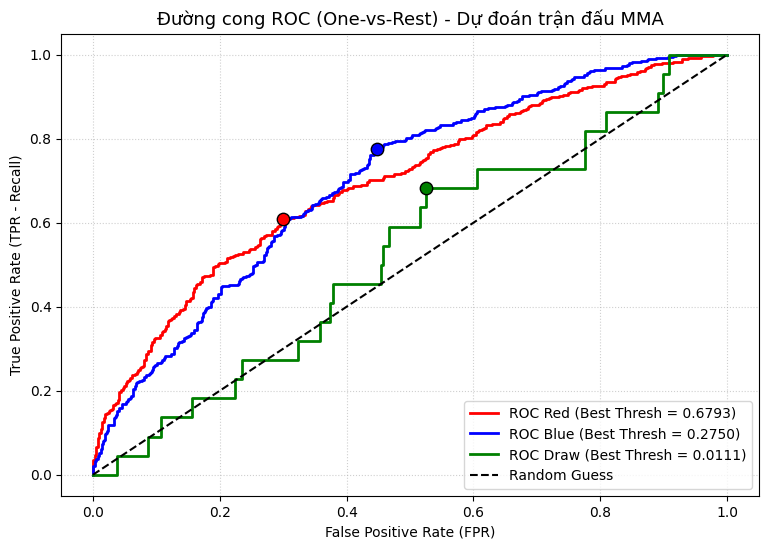

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. TẢI VÀ LÀM SẠCH DỮ LIỆU MMA
# ==========================================
df = pd.read_csv('data.csv')
display(df.head())

# Loại bỏ biến mục tiêu và toàn bộ các cột định danh/metadata gây overfitting
drop_cols = [
    'Winner',
    'R_fighter', 'B_fighter', 'R_name', 'B_name',
    'Referee', 'date', 'Date', 'location', 'Location'
]
valid_cols = [col for col in df.columns if col not in drop_cols]

X = df[valid_cols]
# Ánh xạ 3 lớp: Red -> 0, Blue -> 1, Draw -> 2
y = df['Winner'].map({'Red': 0, 'Blue': 1, 'Draw': 2})

# Loại bỏ các dòng bị thiếu nhãn Winner
valid_idx = y.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx].astype(int)

# Chuyển các cột chữ thành biến nhị phân 0/1 (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# ==========================================
# 2. CHIA TẬP DỮ LIỆU & XỬ LÝ NaN / CHUẨN HÓA
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Điền dữ liệu thiếu bằng trung vị (median)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Chuẩn hóa dữ liệu về cùng thang đo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH SOFTMAX (MULTINOMIAL)
# ==========================================
model = LogisticRegression(
     solver='lbfgs', max_iter=1000, C=0.5
)
model.fit(X_train, y_train)

# P(Red), P(Blue), P(Draw)
y_probs = model.predict_proba(X_test)
y_pred_default = np.argmax(y_probs, axis=1)

print('--- KẾT QUẢ HUẤN LUYỆN SOFTMAX (MẶC ĐỊNH ARGMAX) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_default):.4f}')
print(
    classification_report(
        y_test, y_pred_default, target_names=['Red', 'Blue', 'Draw']
    )
)

# Kiểm tra phân phối xác suất dự đoán (Check Overconfidence)
print('--- KIỂM TRA DẢI XÁC SUẤT DỰ ĐOÁN ---')
for idx, c_name in enumerate(['Red', 'Blue', 'Draw']):
    print(
        f"Lớp {c_name:4s} | Min: {y_probs[:, idx].min():.4f} | Max: {y_probs[:, idx].max():.4f}"
    )
print('-' * 45)

# ==========================================
# 4. VẼ ĐỒ THỊ ROC CHO BÀI 3 LỚP (ONE-VS-REST)
# ==========================================
plt.figure(figsize=(9, 6))

classes = ['Red', 'Blue', 'Draw']
colors = ['red', 'blue', 'green']

for i, (class_name, color) in enumerate(zip(classes, colors)):
    # Đưa về bài toán nhị phân: Lớp i là 1, các lớp khác là 0
    y_test_binary = (y_test == i).astype(int)
    class_probs = y_probs[:, i]

    fpr, tpr, thresholds = roc_curve(y_test_binary, class_probs)

    # Tìm ngưỡng tối ưu cho riêng lớp này bằng Youden Index
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]

    # Dùng :.4f để hiển thị chính xác các ngưỡng nhỏ/lớn
    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f'ROC {class_name} (Best Thresh = {best_threshold:.4f})',
    )
    plt.scatter(
        fpr[best_idx],
        tpr[best_idx],
        color=color,
        s=80,
        edgecolors='black',
        zorder=5,
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Đường cong ROC (One-vs-Rest) - Dự đoán trận đấu MMA', fontsize=13)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR - Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Cho bộ dữ liệu WA_Fn-UseC_-Telco-Customer-Churn.csv chứa thông tin hợp đồng và dịch vụ của khách hàng viễn thông. Hãy thực hiện tiền xử lý dữ liệu và huấn luyện mô hình Logistic Regression để dự đoán xem một khách hàng có hủy dịch vụ (Churn = Yes/No) hay không. In ra kết quả đánh giá mô hình trên tập Test."

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


--- KẾT QUẢ TỐI ƯU HÓA THEO ROC ---
AUC Score         : 0.8319
Ngưỡng tối ưu     : 0.2881
TPR (Recall)      : 0.7807
FPR               : 0.2575

=== BẢNG SO SÁNH NHANH GIỮA 2 NGƯỠNG ===


,Ngưỡng 0.5 (Mặc định),Ngưỡng 0.29 (Tối ưu Youden)
Accuracy,0.7868,0.7527
Recall (Churn),0.5160,0.7807
Precision (Churn),0.6186,0.5233
F1-Score (Churn),0.5627,0.6266



==> 1. CLASSIFICATION REPORT (Ngưỡng mặc định = 0.50):
              precision    recall  f1-score   support

          No       0.83      0.88      0.86      1033
         Yes       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

==> 2. CLASSIFICATION REPORT (Ngưỡng tối ưu = 0.29):
              precision    recall  f1-score   support

          No       0.90      0.74      0.82      1033
         Yes       0.52      0.78      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



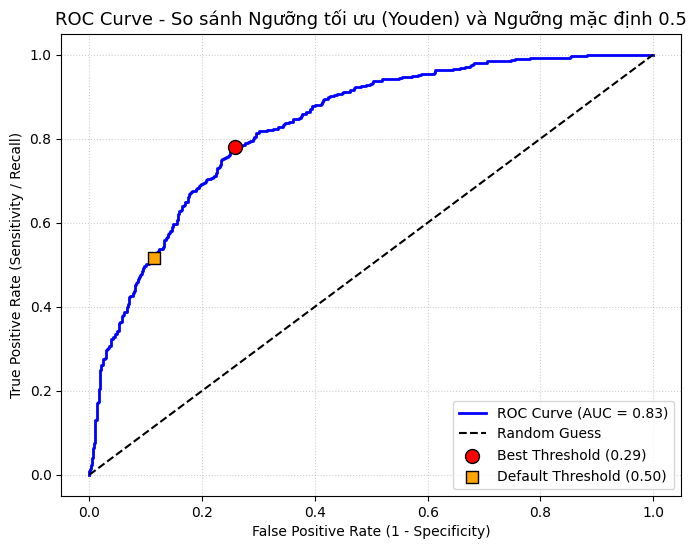

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. TẢI VÀ LÀM SẠCH DỮ LIỆU
# ==========================================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(df.head())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = pd.get_dummies(X, drop_first=True)

# ==========================================
# 2. CHIA TẬP TRAIN/TEST & CHUẨN HÓA
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# ==========================================
# 4. LẤY XÁC SUẤT DỰ ĐOÁN LỚP CHURN (LỚP 1)
# ==========================================
y_probs = model.predict_proba(X_test)[:, 1]

# ==========================================
# 5. TÌM NGƯỠNG TỐI ƯU (YOUDEN'S J STATISTIC)
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(f"--- KẾT QUẢ TỐI ƯU HÓA THEO ROC ---")
print(f"AUC Score         : {roc_auc_score(y_test, y_probs):.4f}")
print(f"Ngưỡng tối ưu     : {best_threshold:.4f}")
print(f"TPR (Recall)      : {tpr[best_idx]:.4f}")
print(f"FPR               : {fpr[best_idx]:.4f}\n")

# ==========================================
# 6. SO SÁNH NGƯỠNG MẶC ĐỊNH 0.5 VÀ NGƯỠNG TỐI ƯU
# ==========================================
# Tạo dự đoán cho cả 2 ngưỡng
y_pred_default = (y_probs >= 0.5).astype(int)
y_pred_optimal = (y_probs >= best_threshold).astype(int)

# Bảng tổng hợp chỉ số nhanh cho lớp Churn (pos_label=1)
comparison_table = pd.DataFrame(
    {
        'Ngưỡng 0.5 (Mặc định)': [
            accuracy_score(y_test, y_pred_default),
            recall_score(y_test, y_pred_default),
            precision_score(y_test, y_pred_default),
            f1_score(y_test, y_pred_default),
        ],
        f'Ngưỡng {best_threshold:.2f} (Tối ưu Youden)': [
            accuracy_score(y_test, y_pred_optimal),
            recall_score(y_test, y_pred_optimal),
            precision_score(y_test, y_pred_optimal),
            f1_score(y_test, y_pred_optimal),
        ],
    },
    index=['Accuracy', 'Recall (Churn)', 'Precision (Churn)', 'F1-Score (Churn)'],
)

print("=== BẢNG SO SÁNH NHANH GIỮA 2 NGƯỠNG ===")
display(comparison_table.round(4))
print("\n" + "=" * 55)

# Chi tiết Classification Report
print("==> 1. CLASSIFICATION REPORT (Ngưỡng mặc định = 0.50):")
print(classification_report(y_test, y_pred_default, target_names=['No', 'Yes']))

print(
    f"==> 2. CLASSIFICATION REPORT (Ngưỡng tối ưu = {best_threshold:.2f}):"
)
print(classification_report(y_test, y_pred_optimal, target_names=['No', 'Yes']))

# ==========================================
# 7. VẼ ĐƯỜNG CONG ROC VÀ ĐIỂM NGƯỠNG SO SÁNH
# ==========================================
# Tìm tọa độ FPR/TPR của ngưỡng gần 0.5 nhất trên đồ thị
default_idx = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_probs):.2f})',
    color='blue',
    lw=2,
)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Đánh dấu Ngưỡng tối ưu (Màu đỏ)
plt.scatter(
    fpr[best_idx],
    tpr[best_idx],
    marker='o',
    color='red',
    s=100,
    edgecolors='black',
    zorder=5,
    label=f'Best Threshold ({best_threshold:.2f})',
)

# Đánh dấu Ngưỡng mặc định 0.5 (Màu cam)
plt.scatter(
    fpr[default_idx],
    tpr[default_idx],
    marker='s',
    color='orange',
    s=80,
    edgecolors='black',
    zorder=5,
    label=f'Default Threshold (0.50)',
)

plt.title(
    'ROC Curve - So sánh Ngưỡng tối ưu (Youden) và Ngưỡng mặc định 0.5',
    fontsize=13,
)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()